# Calcul de coefficients de polarisation

In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [5]:
with open('Q174606.pickle', 'rb') as f:
    G = pickle.load(f)
G = G.to_undirected()

In [6]:
dico_periods = {}
for node in G.nodes():
    period = node.get_era()
    if period not in dico_periods:
        dico_periods[period] = [node]
    else:
        dico_periods[period].append(node)
del dico_periods['Unknown']

In [22]:
def polarization_coefficient(period1,period2):
    nodes1 = dico_periods[period1]
    nodes2 = dico_periods[period2]
    subgraph = G.subgraph(nodes1 + nodes2)
    B12 = set()
    B21 = set()
    I1 = set(nodes1)
    I2 = set(nodes2)
    for u in nodes1:
        for v in nodes2:
            if G.has_edge(u,v):
                B12.add(u)
                B21.add(v)
    I1 = I1 - B12
    I2 = I2 - B21
    s = 0
    for v in B12:
        di=0
        db = 0
        for w in subgraph.neighbors(v):
            if w in I1:
                di += 1
            elif w in B21:
                db += 1
        s += (di/(di+db)) - 0.5
    for v in B21:
        di=0
        db = 0
        for w in subgraph.neighbors(v):
            if w in I2:
                di += 1
            elif w in B12:
                db += 1
        s += (di/(di+db)) - 0.5
    if len(B12) + len(B21) == 0:
        return 0
    return s / (len(B12) + len(B21))

Text(0.5, 1.0, 'Polarization Coefficient Heatmap')

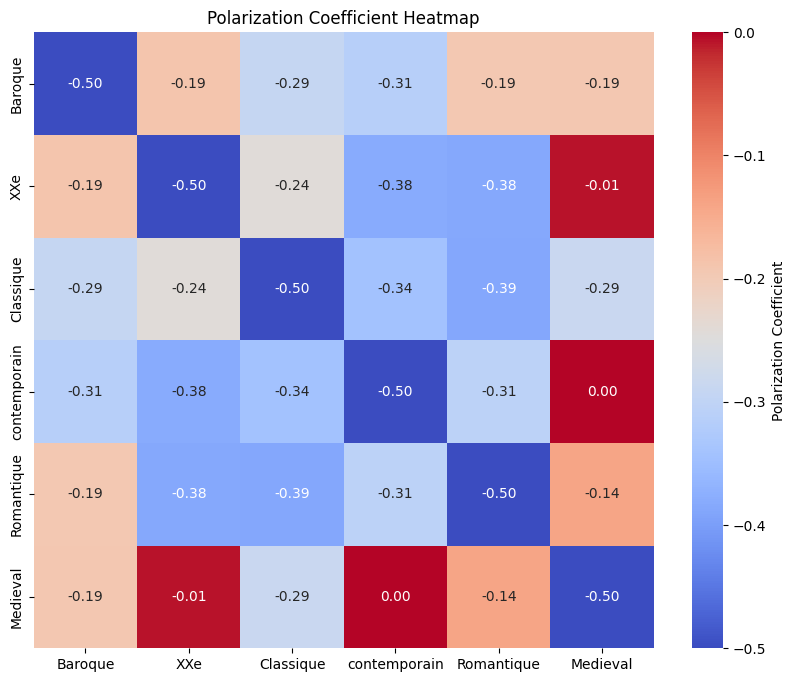

In [24]:
matrix = np.zeros((len(dico_periods), len(dico_periods)))
periods = list(dico_periods.keys())
for i in range(len(periods)):
    for j in range(len(periods)):
            matrix[i][j] = polarization_coefficient(periods[i], periods[j])
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, fmt=".2f", xticklabels=periods, yticklabels=periods, cmap='coolwarm', cbar_kws={'label': 'Polarization Coefficient'})
plt.title('Polarization Coefficient Heatmap')